# Can we stop the experiment early?

Every panel below asks one question: **if we had stopped collecting data at
this moment, what would we have predicted for the rest of the curve, and how
wrong would we have been?**

Each experiment is shown at four evenly spaced stopping points (20%, 40%,
60%, 80% of the way through). At each stopping point three forecasts are
drawn from that moment to the end of the experiment:

| Line | What it is |
|---|---|
| **Complete-series fit** (green, dashed) | The kinetic model fitted to *all* the data, including the part we are pretending not to have. This is the answer we are trying to reach early. It is the best any method could do. |
| **Fit to data so far** (orange) | The kinetic model fitted only to the points collected up to the stopping line. No machine learning. This is what you get today by just fitting whatever you have. |
| **Deployed forecast** (blue) | The currently deployed sequential model. It is the random forest, which predicts from experiment setup only — so its curve does not change as data arrives. That is a finding, not a bug, and these plots make it visible. |

Filled black points are data that had been collected at the stopping point.
Hollow grey points are the future the forecast is trying to predict.

All experiments shown are from the **test set** — experiments that were never
used to train or to choose anything. This notebook only re-draws forecasts
that were already computed and frozen; it does not fit or select anything.

In [11]:
import json
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AUTOMATION_DIR = Path.cwd()
while not (AUTOMATION_DIR / 'sequential_forecasting' / 'artifacts').exists():
    AUTOMATION_DIR = AUTOMATION_DIR.parent
    if AUTOMATION_DIR == AUTOMATION_DIR.parent:
        raise FileNotFoundError('Could not locate automation directory')
sys.path.insert(0, str(AUTOMATION_DIR))
logging.disable(logging.CRITICAL)  # the flattener logs one line per file

from sequential_forecasting.data.contract import AREA_COLUMN, TIME_COLUMN
from sequential_forecasting.data.examples import FIT_VALID, build_sequential_examples
from sequential_forecasting.data.observations import flatten_monomer_rows
from sequential_forecasting.models.secondary_pfo import (
    OdeForecastError,
    SecondaryPfoParameters,
    build_cutoff_forecast,
    remaining_curve_rmse,
)

ARTIFACT_DIR = AUTOMATION_DIR / 'sequential_forecasting' / 'artifacts' / 'phase0'
RUN_CONFIG = json.loads((ARTIFACT_DIR / 'run_config.json').read_text(encoding='utf-8'))
MIN_FIT_POINTS = int(RUN_CONFIG['minimum_fit_points'])
TIME_TOLERANCE_S = float(RUN_CONFIG['time_tolerance_s'])

records_by_experiment = {}
with (ARTIFACT_DIR / 'inference' / 'predictions.jsonl').open(encoding='utf-8') as handle:
    for line in handle:
        record = json.loads(line)
        if record['assignment'] != 'test':
            continue
        records_by_experiment.setdefault(record['experiment_id'], []).append(record)
for rows in records_by_experiment.values():
    rows.sort(key=lambda row: row['cutoff_time_s'])

print(f'{sum(len(v) for v in records_by_experiment.values())} frozen test forecasts '
      f'across {len(records_by_experiment)} experiments')
print(f"deployed model: {next(iter(records_by_experiment.values()))[0]['model_candidate']}")

2312 frozen test forecasts across 49 experiments
deployed model: rf_only


In [12]:
STOP_FRACTIONS = (0.2, 0.4, 0.6, 0.8)
COLOR_REFERENCE = '#059669'
COLOR_CURRENT_FIT = '#ea580c'
COLOR_DEPLOYED = '#2563eb'


def load_experiment(experiment_id):
    """Observed series plus one leakage-safe example per cutoff."""
    rows = records_by_experiment[experiment_id]
    csv_path = rows[0]['csv_path']
    json_path = rows[0]['json_path']
    flags = json.loads(Path(json_path).read_text(encoding='utf-8')).get('filename_flags', {})
    flattened, _ = flatten_monomer_rows(
        pd.read_csv(csv_path), time_tolerance_s=TIME_TOLERANCE_S
    )
    final_time_s = rows[0]['final_time_s']
    timeline = flattened.loc[flattened[TIME_COLUMN] <= final_time_s]
    times = timeline[TIME_COLUMN].to_numpy(float)
    areas = timeline[AREA_COLUMN].to_numpy(float)
    examples = build_sequential_examples(
        pd.read_csv(csv_path),
        experiment_id=experiment_id,
        successful=bool(flags.get('success', flags.get('exp_success', False))),
        min_points=MIN_FIT_POINTS,
        time_tolerance_s=TIME_TOLERANCE_S,
    )
    return times, areas, examples, {row['cutoff_time_s']: row for row in rows}


def forecast_from(parameters, times, areas, cutoff_s, final_time_s):
    """Curve through the end of the experiment, plus its error after the cutoff."""
    if parameters is None:
        return None
    try:
        forecast = build_cutoff_forecast(
            times, areas, cutoff_s, parameters,
            final_time_s=final_time_s, timeout_seconds=1.0,
        )
    except (OdeForecastError, ValueError):
        return None
    rmse = remaining_curve_rmse(
        forecast.times_s, areas[: len(forecast.times_s)],
        forecast.predicted_area, cutoff_s,
    )
    return forecast.times_s, forecast.predicted_area, rmse


def reference_parameters(example):
    return SecondaryPfoParameters.from_values(example.reference_target)


def current_fit_parameters(example):
    """The kinetic model fitted to the data available at this cutoff, or None."""
    if example.fit_status != FIT_VALID:
        return None
    values = list(example.current_fit_values)
    if any(value is None for value in values):
        return None
    values[-1] = example.q_0
    return SecondaryPfoParameters.from_values(values)


def pick_stop_examples(examples, final_time_s):
    """One example per evenly spaced stopping point, by elapsed time."""
    chosen = []
    for fraction in STOP_FRACTIONS:
        target = fraction * final_time_s
        chosen.append(min(examples, key=lambda e: abs(e.cutoff_time_s - target)))
    return chosen


print(f'stopping points: {", ".join(f"{f:.0%}" for f in STOP_FRACTIONS)} of experiment duration')

stopping points: 20%, 40%, 60%, 80% of experiment duration


## Four stopping points through each experiment

Read each row left to right: the black points grow, the stopping line moves
right, and the question is whether the forecasts converge onto the green
dashed line — the answer you would get by running the experiment to the end.

The number in each panel is the forecast error over the *remaining*
(un-collected) part of the curve, in the same units as the vertical axis.

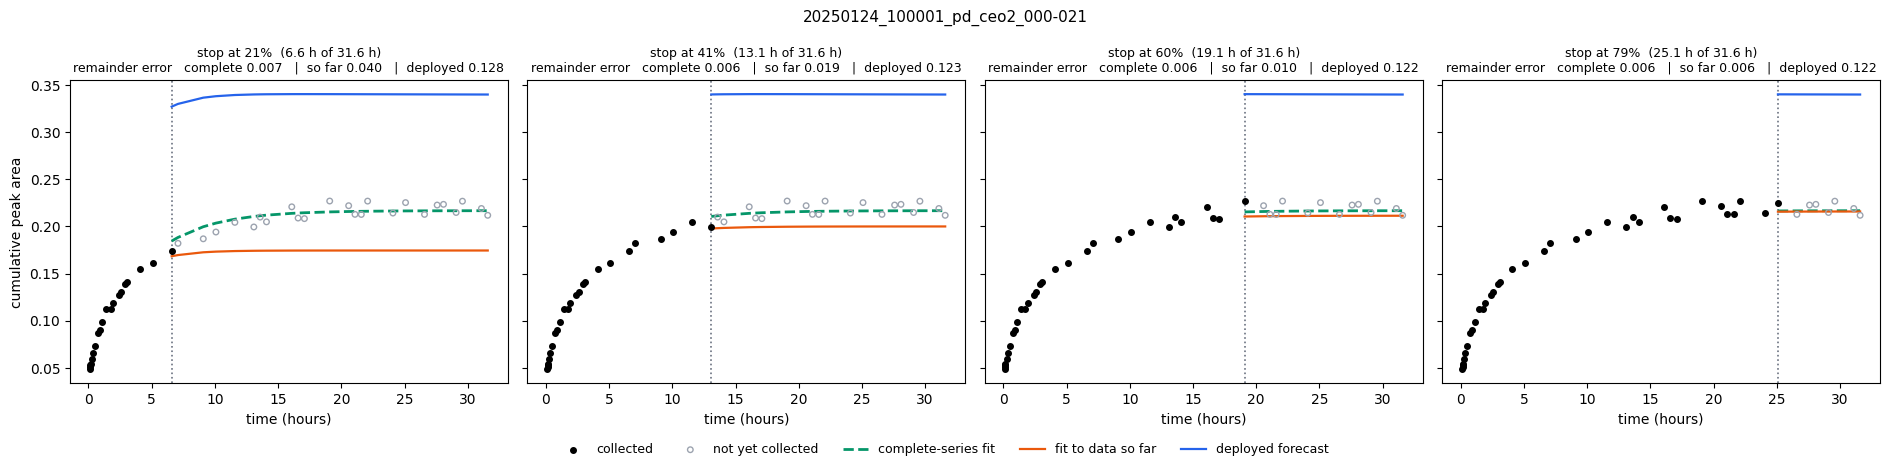

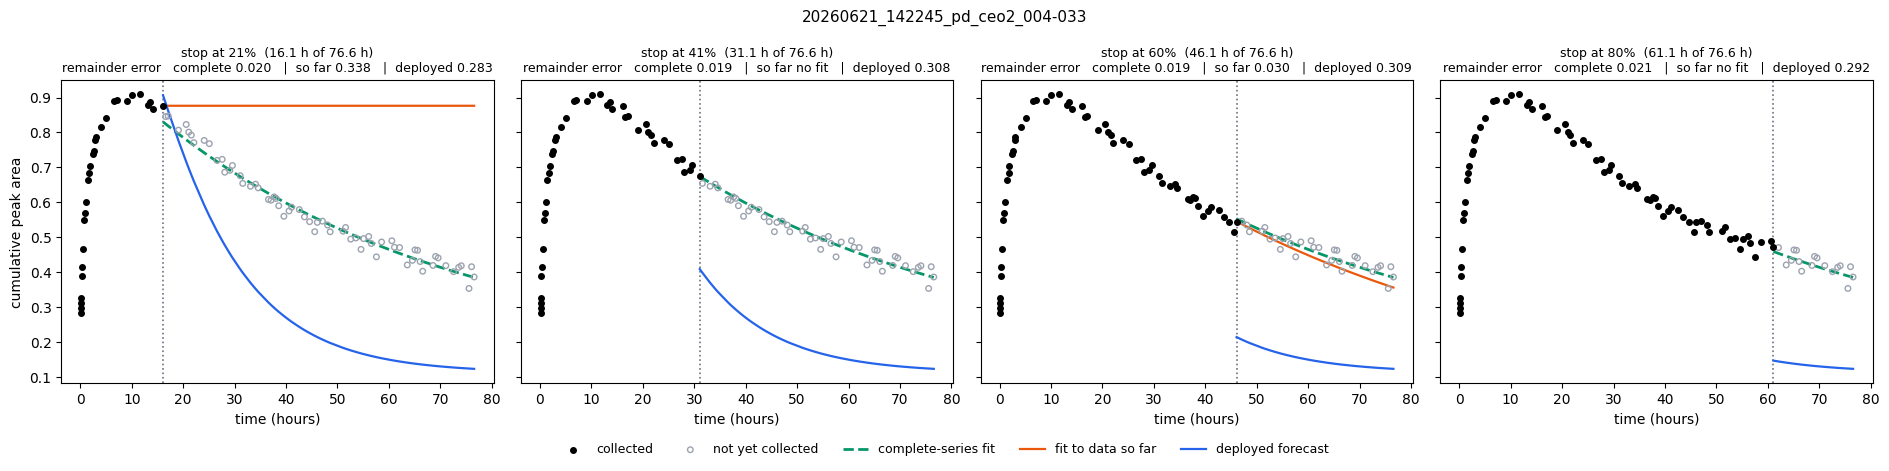

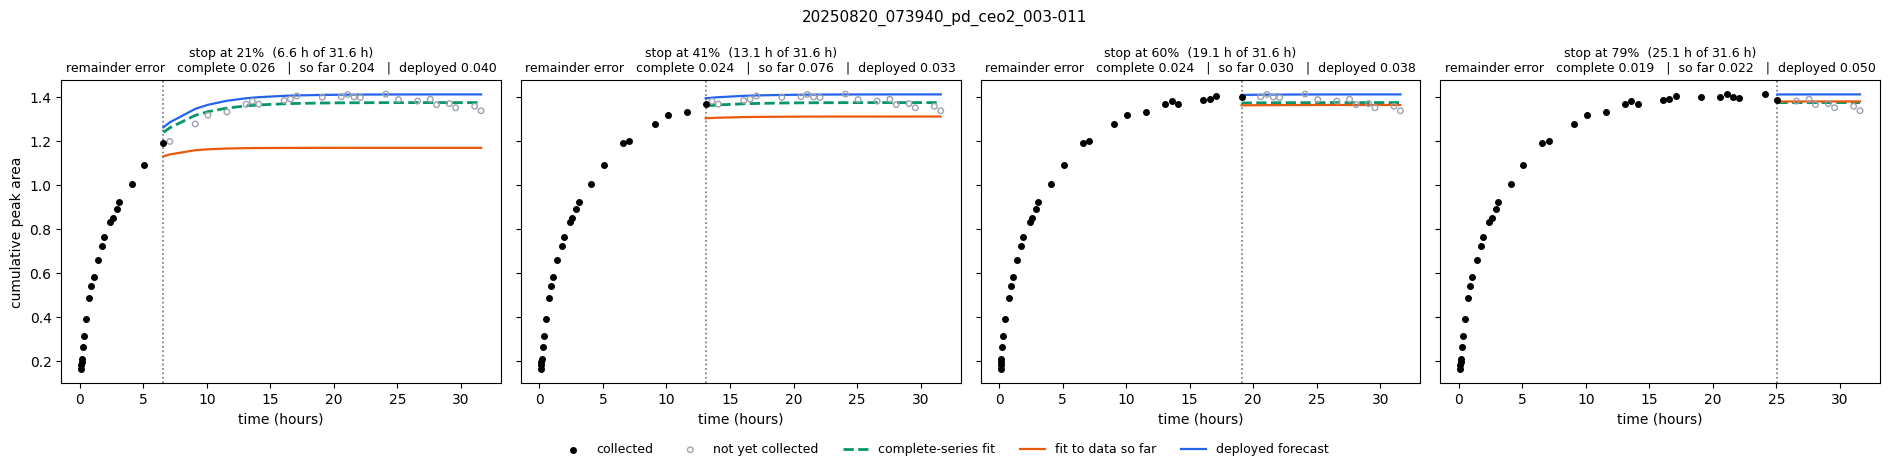

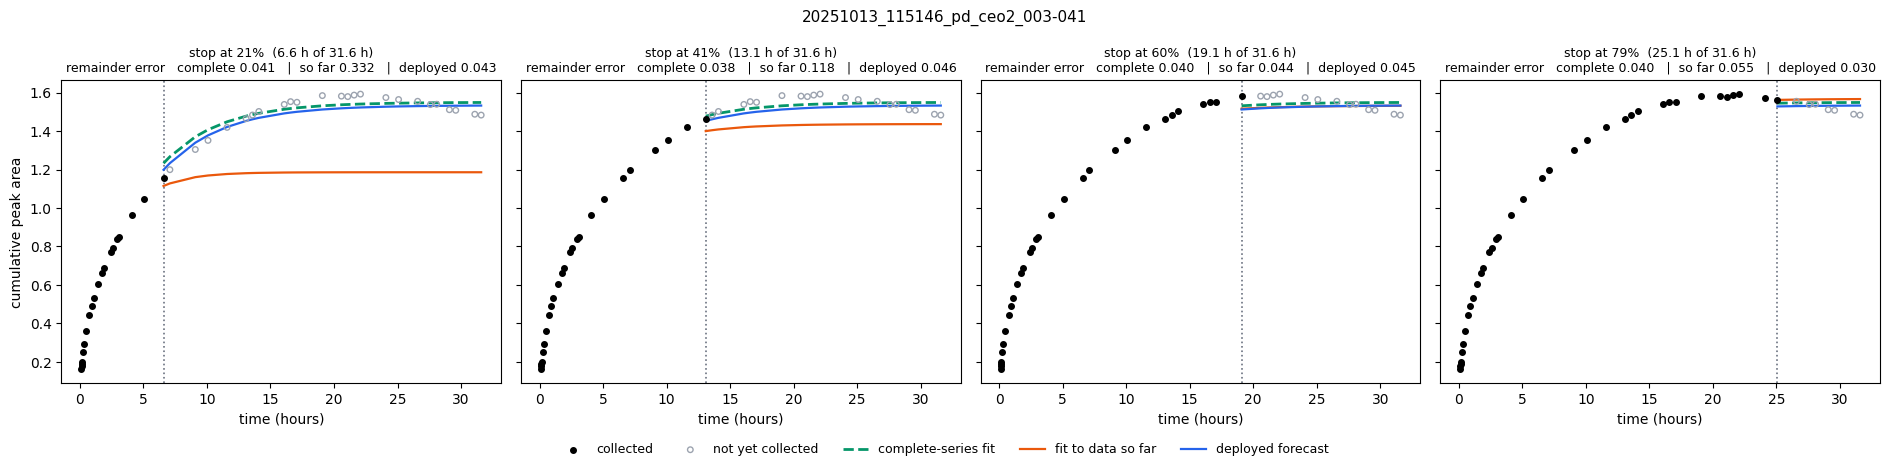

In [13]:
# Show a spread of behaviours rather than whichever experiments sort first:
# pick across the range of final adsorption capacity.
capacity = {}
for experiment_id in records_by_experiment:
    _, _, examples, _ = load_experiment(experiment_id)
    capacity[experiment_id] = float(examples[-1].reference_target[1])
ordered = sorted(capacity, key=capacity.get)
SHOWCASE = [ordered[int(q * (len(ordered) - 1))] for q in (0.15, 0.45, 0.7, 0.92)]

for experiment_id in SHOWCASE:
    times, areas, examples, records = load_experiment(experiment_id)
    final_time_s = examples[-1].final_time_s
    stops = pick_stop_examples(examples, final_time_s)

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.4), sharey=True)
    for axis, example in zip(axes, stops):
        cutoff_s = example.cutoff_time_s
        collected = times <= cutoff_s
        axis.scatter(times[collected] / 3600, areas[collected], c='black', s=16,
                     zorder=6, label='collected')
        axis.scatter(times[~collected] / 3600, areas[~collected], s=16, zorder=5,
                     facecolors='none', edgecolors='#9ca3af', label='not yet collected')
        axis.axvline(cutoff_s / 3600, color='#6b7280', linestyle=':', linewidth=1.2)

        scores = {}
        for name, parameters, color, style, width in (
            ('complete-series fit', reference_parameters(example), COLOR_REFERENCE, '--', 2.0),
            ('fit to data so far', current_fit_parameters(example), COLOR_CURRENT_FIT, '-', 1.6),
        ):
            result = forecast_from(parameters, times, areas, cutoff_s, final_time_s)
            if result is None:
                scores[name] = None
                continue
            curve_times, curve_area, rmse = result
            ahead = curve_times >= cutoff_s
            axis.plot(curve_times[ahead] / 3600, curve_area[ahead], color=color,
                      linestyle=style, linewidth=width, zorder=4, label=name)
            scores[name] = rmse

        record = records.get(cutoff_s)
        if record is not None and record['curve_status'] == 'valid':
            curve_times = np.asarray(record['curve_times_s'], float)
            curve_area = np.asarray(record['curve_predicted_area'], float)
            ahead = curve_times >= cutoff_s
            axis.plot(curve_times[ahead] / 3600, curve_area[ahead], color=COLOR_DEPLOYED,
                      linewidth=1.6, zorder=4, label='deployed forecast')
            scores['deployed forecast'] = remaining_curve_rmse(
                curve_times, areas[: len(curve_times)], curve_area, cutoff_s
            )

        def show_score(name):
            value = scores.get(name)
            return f'{value:.3f}' if value is not None else 'no fit'

        axis.set_title(
            f'stop at {cutoff_s / final_time_s:.0%}'
            f'  ({cutoff_s / 3600:.1f} h of {final_time_s / 3600:.1f} h)\n'
            f'remainder error   complete {show_score("complete-series fit")}'
            f'   |  so far {show_score("fit to data so far")}'
            f'   |  deployed {show_score("deployed forecast")}',
            fontsize=9,
        )
        axis.set_xlabel('time (hours)')
    axes[0].set_ylabel('cumulative peak area')
    handles, names = axes[0].get_legend_handles_labels()
    fig.legend(handles, names, loc='lower center', ncol=5, frameon=False,
               bbox_to_anchor=(0.5, -0.06), fontsize=9)
    fig.suptitle(experiment_id, fontsize=11)
    fig.tight_layout()
    plt.show()

## Same curve, very different numbers

This is the single most important thing to see, because it explains why "more
accurate parameters" has not been producing better forecasts.

At the 60% stopping point, the left panel draws two curves: the kinetic model
fitted to the data so far, and the kinetic model fitted to everything. They sit
almost on top of each other. The right panel shows the five parameters behind
those two nearly identical curves, as a ratio. If the curves agree but the bars
are far from 1, then the parameters are **not individually pinned down by the
data** — several different combinations draw the same curve.

That matters for modelling: a model trained to get each parameter close, one at
a time, can succeed at that and still draw the wrong curve, because what the
curve depends on is the combination.

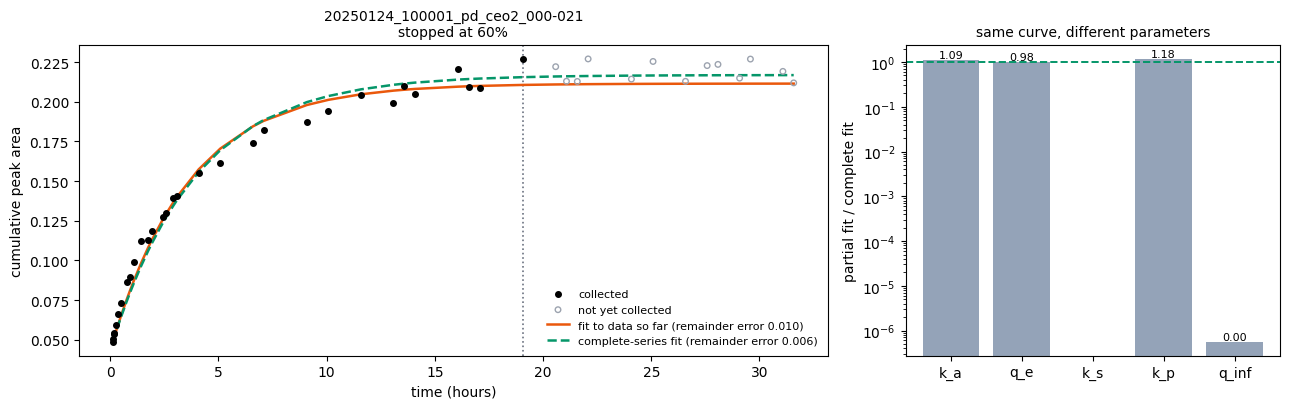

       fit to data so far  complete-series fit       ratio
k_a           7.70883e-05           7.0833e-05     1.08831
q_e              0.211435             0.216826    0.975134
k_s                     0                    0         NaN
k_p           4.18561e-05          3.55074e-05      1.1788
q_inf         1.18363e-09           0.00208654 5.67268e-07



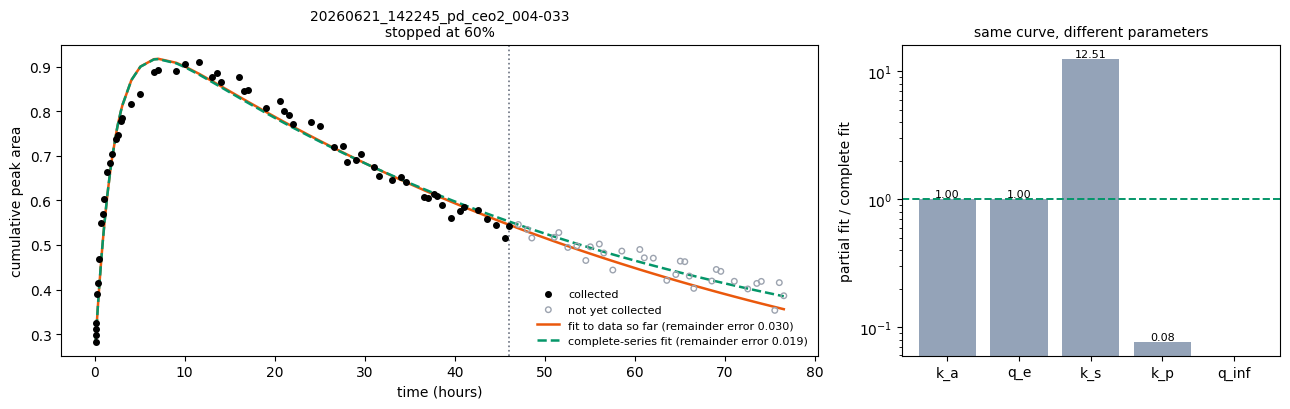

       fit to data so far  complete-series fit     ratio
k_a           0.000134722          0.000134574    1.0011
q_e              0.992272             0.993308  0.998957
k_s                  0.01          0.000799044    12.515
k_p           5.16797e-08           6.7063e-07 0.0770614
q_inf                   0                    0       NaN



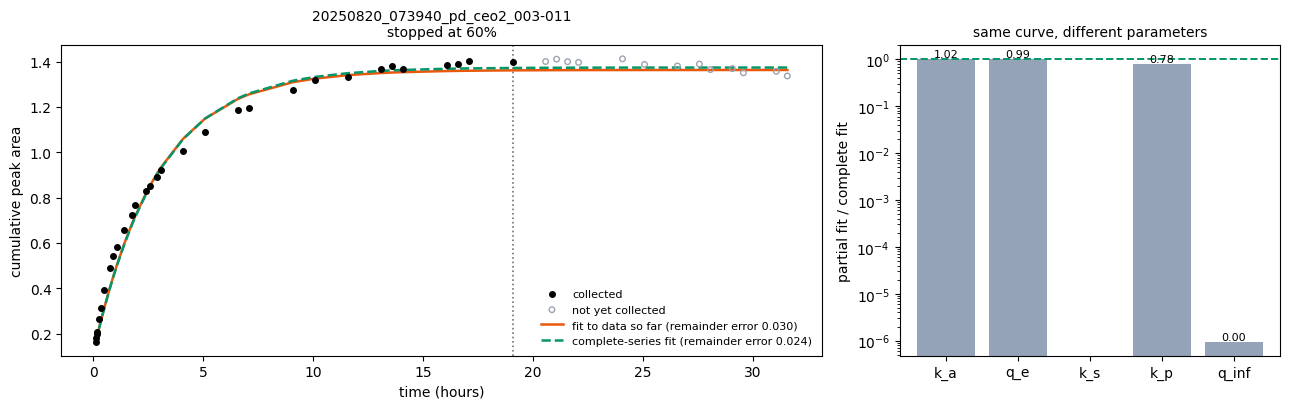

       fit to data so far  complete-series fit       ratio
k_a           9.61337e-05          9.39846e-05     1.02287
q_e                1.3634              1.37424    0.992108
k_s                     0                    0         NaN
k_p           4.97019e-05          6.33719e-05     0.78429
q_inf         8.02431e-09           0.00840706 9.54472e-07



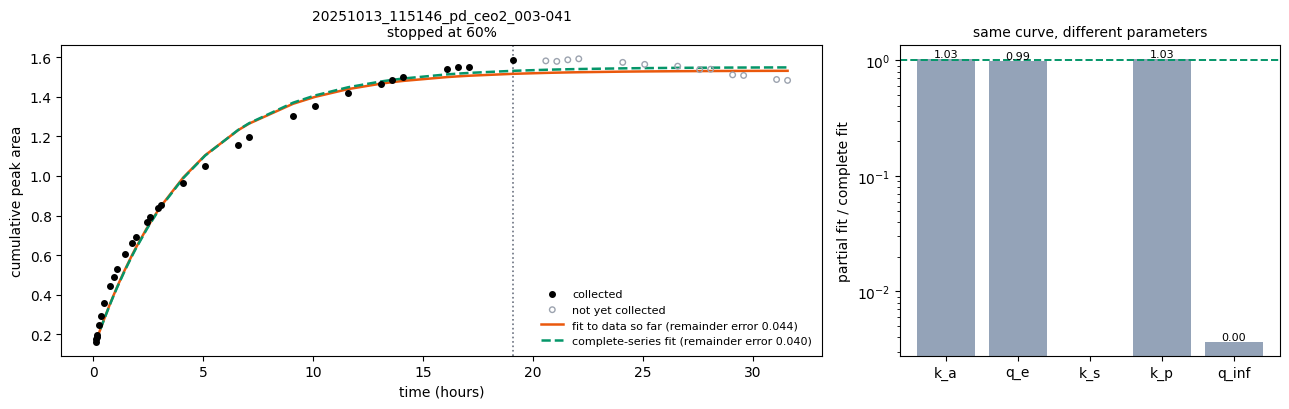

       fit to data so far  complete-series fit      ratio
k_a           6.50802e-05          6.33543e-05    1.02724
q_e               1.53247              1.54992   0.988741
k_s                     0                    0        NaN
k_p           3.36102e-05          3.25202e-05    1.03352
q_inf         1.64304e-11          4.46574e-09 0.00367921



In [14]:
PARAMETER_LABELS = ('k_a', 'q_e', 'k_s', 'k_p', 'q_inf')

for experiment_id in SHOWCASE:
    times, areas, examples, _ = load_experiment(experiment_id)
    final_time_s = examples[-1].final_time_s
    example = min(examples, key=lambda e: abs(e.cutoff_time_s - 0.6 * final_time_s))
    partial = current_fit_parameters(example)
    complete = reference_parameters(example)
    if partial is None:
        print(f'{experiment_id}: no valid fit at the 60% stop')
        continue

    cutoff_s = example.cutoff_time_s
    fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.2),
                                      gridspec_kw={'width_ratios': [2, 1]})
    collected = times <= cutoff_s
    left.scatter(times[collected] / 3600, areas[collected], c='black', s=16, zorder=6,
                 label='collected')
    left.scatter(times[~collected] / 3600, areas[~collected], s=16, zorder=5,
                 facecolors='none', edgecolors='#9ca3af', label='not yet collected')
    left.axvline(cutoff_s / 3600, color='#6b7280', linestyle=':', linewidth=1.2)
    for name, parameters, color, style in (
        ('fit to data so far', partial, COLOR_CURRENT_FIT, '-'),
        ('complete-series fit', complete, COLOR_REFERENCE, '--'),
    ):
        result = forecast_from(parameters, times, areas, cutoff_s, final_time_s)
        if result is None:
            continue
        curve_times, curve_area, rmse = result
        label = f'{name} (remainder error {rmse:.3f})' if rmse is not None else name
        left.plot(curve_times / 3600, curve_area, color=color, linestyle=style,
                  linewidth=1.8, zorder=4, label=label)
    left.set_xlabel('time (hours)')
    left.set_ylabel('cumulative peak area')
    left.set_title(f'{experiment_id}\nstopped at {cutoff_s / final_time_s:.0%}', fontsize=10)
    left.legend(frameon=False, fontsize=8, loc='lower right')

    a = partial.as_array()[:5]
    b = complete.as_array()[:5]
    ratio = np.where(b != 0, a / np.where(b == 0, 1.0, b), np.nan)
    right.bar(PARAMETER_LABELS, np.nan_to_num(ratio, nan=0.0), color='#94a3b8')
    right.axhline(1.0, color=COLOR_REFERENCE, linestyle='--', linewidth=1.4)
    right.set_yscale('log')
    right.set_ylabel('partial fit / complete fit')
    right.set_title('same curve, different parameters', fontsize=10)
    for index, value in enumerate(ratio):
        if np.isfinite(value) and value > 0:
            right.text(index, value, f'{value:.2f}', ha='center', va='bottom', fontsize=8)
    fig.tight_layout()
    plt.show()

    table = pd.DataFrame(
        {'fit to data so far': a, 'complete-series fit': b, 'ratio': ratio},
        index=list(PARAMETER_LABELS),
    )
    print(table.to_string(float_format=lambda v: f'{v:.6g}'))
    print()

## How early could we have stopped?

The panels above are four experiments. This is all 49 test experiments at
once, and it is the chart that answers the practical question.

**Left:** average error over the un-collected remainder of the curve, against
how far through the experiment you stopped. **Right:** the error in the
predicted *final* value — where the curve ends up — which is usually the
number an experimenter actually wants.

The green line is the complete-series fit applied at every stopping point. It
is flat because it always knows the answer; it is the floor, and the distance
between any other line and the green one is the room still available.

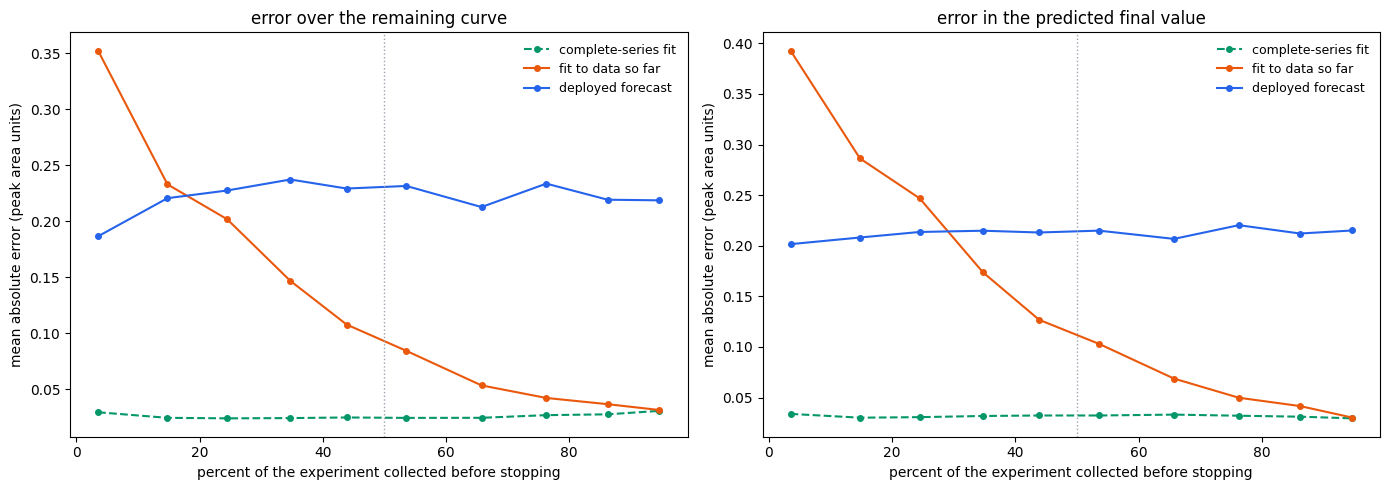

mean error over the remaining curve, by how much was collected:
         complete-series fit  fit to data so far  deployed forecast
0-10%                 0.0293              0.3524             0.1866
10-20%                0.0244              0.2330             0.2206
20-30%                0.0239              0.2018             0.2275
30-40%                0.0241              0.1467             0.2373
40-50%                0.0247              0.1077             0.2292
50-60%                0.0243              0.0842             0.2315
60-70%                0.0244              0.0533             0.2127
70-80%                0.0268              0.0421             0.2336
80-90%                0.0275              0.0365             0.2192
90-100%               0.0306              0.0313             0.2187


In [15]:
rows = []
for experiment_id in records_by_experiment:
    times, areas, examples, records = load_experiment(experiment_id)
    final_time_s = examples[-1].final_time_s
    observed_final = float(areas[-1])
    for example in examples:
        cutoff_s = example.cutoff_time_s
        if cutoff_s >= final_time_s:
            continue
        entry = {'elapsed': cutoff_s / final_time_s}
        sources = {
            'complete-series fit': reference_parameters(example),
            'fit to data so far': current_fit_parameters(example),
        }
        for name, parameters in sources.items():
            result = forecast_from(parameters, times, areas, cutoff_s, final_time_s)
            if result is None or result[2] is None:
                continue
            entry[name] = result[2]
            entry[f'{name} final'] = abs(float(result[1][-1]) - observed_final)
        record = records.get(cutoff_s)
        if record is not None and record['curve_status'] == 'valid':
            curve_times = np.asarray(record['curve_times_s'], float)
            curve_area = np.asarray(record['curve_predicted_area'], float)
            rmse = remaining_curve_rmse(curve_times, areas[: len(curve_times)],
                                        curve_area, cutoff_s)
            if rmse is not None:
                entry['deployed forecast'] = rmse
                entry['deployed forecast final'] = abs(float(curve_area[-1]) - observed_final)
        rows.append(entry)

frame = pd.DataFrame(rows)
frame['bin'] = np.clip((frame['elapsed'] * 10).astype(int), 0, 9)
centres = (frame.groupby('bin')['elapsed'].mean() * 100)

styles = {
    'complete-series fit': (COLOR_REFERENCE, '--'),
    'fit to data so far': (COLOR_CURRENT_FIT, '-'),
    'deployed forecast': (COLOR_DEPLOYED, '-'),
}
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))
for name, (color, style) in styles.items():
    if name in frame:
        left.plot(centres, frame.groupby('bin')[name].mean(), color=color,
                  linestyle=style, marker='o', markersize=4, label=name)
    column = f'{name} final'
    if column in frame:
        right.plot(centres, frame.groupby('bin')[column].mean(), color=color,
                   linestyle=style, marker='o', markersize=4, label=name)

left.set_title('error over the remaining curve')
right.set_title('error in the predicted final value')
for axis in (left, right):
    axis.set_xlabel('percent of the experiment collected before stopping')
    axis.set_ylabel('mean absolute error (peak area units)')
    axis.axvline(50, color='#9ca3af', linewidth=1, linestyle=':')
    axis.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

summary = frame.groupby('bin')[[c for c in styles if c in frame]].mean()
summary.index = [f'{int(i * 10)}-{int(i * 10 + 10)}%' for i in summary.index]
print('mean error over the remaining curve, by how much was collected:')
print(summary.round(4).to_string())